# Assignment 3 — Authorship Attribution

Predict the author (20 classes) of each fanfiction snippet.

In [1]:
from src.dataloader import load_all

splits = load_all()
for name, (texts, authors) in splits.items():
    print(f"{name}: {len(texts)} snippets, {len(set(authors))} authors")

train: 2138 snippets, 20 authors
dev: 268 snippets, 20 authors
test: 267 snippets, 20 authors


In [2]:
# NLTK data and the NRC emotion lexicon; only downloads what is missing
from src.features import download_resources

download_resources()

In [3]:
from src.features import extract_all
from src.model import Classifier

train_texts, train_y = splits["train"]
dev_texts, dev_y = splits["dev"]

train_X = extract_all(train_texts)
dev_X = extract_all(dev_texts)

model = Classifier().train(train_X, train_y)
pred = model.predict(dev_X)

F1 (micro): 0.937
Macro-F1  : 0.923


<Axes: xlabel='Predicted author', ylabel='True author'>

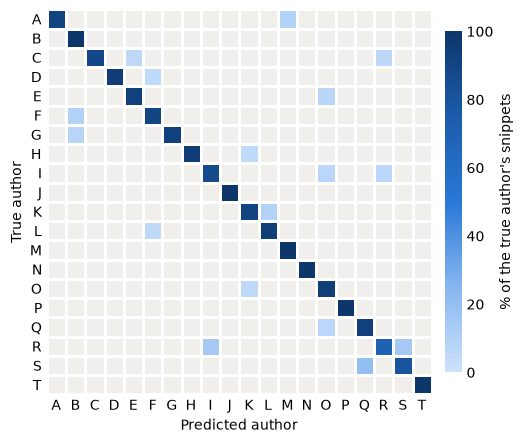

In [4]:
from src.evaluation import f1, macro_f1, confusion

print("F1 (micro):", round(f1(dev_y, pred), 3))
print("Macro-F1  :", round(macro_f1(dev_y, pred), 3))
confusion(dev_y, pred)

## Classifier comparison

In [5]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

classifiers = {
    "linear SVM": LinearSVC(),
    "logistic regression": LogisticRegression(max_iter=5000),
    "random forest": RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1),
}

print(f"{'classifier':<22}{'micro-F1':>10}{'macro-F1':>10}")
for name, clf in classifiers.items():
    clf_pred = Classifier(clf).train(train_X, train_y).predict(dev_X)
    print(f"{name:<22}{f1(dev_y, clf_pred):>10.3f}{macro_f1(dev_y, clf_pred):>10.3f}")

classifier              micro-F1  macro-F1


linear SVM                 0.937     0.923


logistic regression        0.937     0.926


random forest              0.918     0.890


## Ablation analysis

Leave one feature group out at a time and check how the score drops. A lower score means the group was more informative.

150 features in 7 groups


group left out    micro-F1  macro-F1
all (baseline)       0.937     0.926
character            0.910     0.900
punctuation          0.929     0.917
structure            0.948     0.937
lexical              0.940     0.929
syntactic            0.944     0.933
informal             0.922     0.911
semantic             0.944     0.944


<Axes: xlabel='Removed feature group', ylabel='Macro-F1 (dev)'>

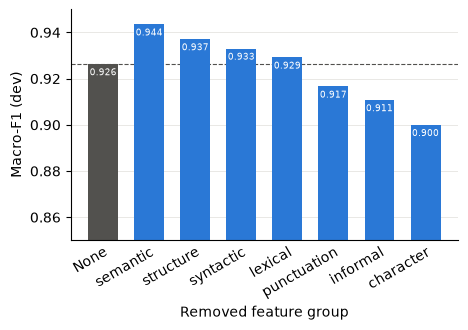

In [6]:
from src.features import FEATURE_NAMES, FEATURE_GROUPS
from src.ablation import ablate, plot_ablation
from sklearn.linear_model import LogisticRegression

print(f"{len(FEATURE_NAMES)} features in {len(FEATURE_GROUPS)} groups")

scores = ablate(FEATURE_GROUPS, train_X, train_y, dev_X, dev_y, clf=LogisticRegression(max_iter=5000))

print(f"{'group left out':<16}{'micro-F1':>10}{'macro-F1':>10}")
for name, m in scores.items():
    label = "all (baseline)" if name == "all" else name
    print(f"{label:<16}{m['micro_f1']:>10.3f}{m['macro_f1']:>10.3f}")

plot_ablation(scores)